In [48]:
# modelling.ipynb
# Member A: Track geometry (A1), Vehicle motion model (A2), Beacon optimisation (A3)

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

np.random.seed(42)  # fix seed for reproducibility

In [49]:
# ── A1: Track geometry ───────────────────────────────────────────────────────
# Track parameters (from problem statement, Figure 1)
R   = 50.0   # outer radius at A (m)
r   = 46.0   # inner radius at A (m)
rho = 20.0   # centreline radius at B (m)
d   = 100.0  # distance between arc centres A and B (m)

R_A = (R + r) / 2   # centreline radius at A = 48.0 m
R_B = rho            # centreline radius at B = 20.0 m
w   = (R - r) / 2   # track half-width = 2.0 m

# Common external tangent geometry
alpha = np.arcsin((R_A - R_B) / d)
cos_a = np.cos(alpha)
sin_a = np.sin(alpha)

l_tan   = np.sqrt(d**2 - (R_A - R_B)**2)   # tangent length
l_arc_A = R_A * (np.pi + 2*alpha)           # large arc length
l_arc_B = R_B * (np.pi - 2*alpha)           # small arc length
L       = 2*l_tan + l_arc_A + l_arc_B       # total perimeter

A_centre = np.array([0.0, 0.0])
B_centre = np.array([d,   0.0])

# Clockwise segment boundaries:
# Seg 1: upper straight  (A -> B)
# Seg 2: small arc at B  (clockwise)
# Seg 3: lower straight  (B -> A)
# Seg 4: large arc at A  (clockwise)
s1 = l_tan
s2 = s1 + l_arc_B
s3 = s2 + l_tan

print(f"R_A = {R_A:.1f} m, R_B = {R_B:.1f} m")
print(f"alpha = {np.degrees(alpha):.3f} deg")
print(f"Tangent length = {l_tan:.3f} m")
print(f"Large arc = {np.degrees(np.pi + 2*alpha):.1f} deg, {l_arc_A:.3f} m")
print(f"Small arc = {np.degrees(np.pi - 2*alpha):.1f} deg, {l_arc_B:.3f} m")
print(f"Track perimeter L = {L:.3f} m")
print(f"One lap at 10 m/s: {L/10:.1f} s")

R_A = 48.0 m, R_B = 20.0 m
alpha = 16.260 deg
Tangent length = 96.000 m
Large arc = 212.5 deg, 178.041 m
Small arc = 147.5 deg, 51.480 m
Track perimeter L = 421.521 m
One lap at 10 m/s: 42.2 s


In [50]:
def s_to_xy(s):
    """
    Arc-length s -> Cartesian (x, y) on track centreline.
    Clockwise travel:
      Seg 1: upper straight  A -> B
      Seg 2: small arc at B  (clockwise)
      Seg 3: lower straight  B -> A
      Seg 4: large arc at A  (clockwise)
    """
    s = s % L
    if s < s1:
        # Seg 1: upper straight, direction (cos_a, -sin_a)
        A_top = A_centre + R_A * np.array([sin_a, cos_a])
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        # Seg 2: small arc at B, clockwise (angle decreasing)
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        # Seg 3: lower straight, direction (-cos_a, -sin_a)
        B_bot = B_centre + R_B * np.array([sin_a, -cos_a])
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        # Seg 4: large arc at A, clockwise (angle decreasing)
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])


def s_to_normal(s):
    """
    Unit outward normal at arc-length s.
    For clockwise travel, outward normal points to the left of the direction of motion.
    ell > 0: outer wall, ell < 0: inner wall.
    """
    s = s % L
    if s < s1:
        return np.array([sin_a, cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])


def sl_to_xy(s, ell):
    """
    (arc-length s, lateral offset ell) -> Cartesian (x, y).
    ell = 0: centreline
    ell = +2: outer wall, ell = -2: inner wall
    """
    return s_to_xy(s) + ell * s_to_normal(s)

Track width checks (should all be 4.000 m):
  s=   0.0: width = 4.0000 m
  s=  48.0: width = 4.0000 m
  s=  96.0: width = 4.0000 m
  s= 140.5: width = 4.0000 m
  s= 147.5: width = 4.0000 m
  s= 195.5: width = 4.0000 m
  s= 243.5: width = 4.0000 m
  s= 269.2: width = 4.0000 m

Normal unit length checks (should all be 1.000000):
  s=   0.0: |n| = 1.000000
  s=  48.0: |n| = 1.000000
  s=  96.0: |n| = 1.000000
  s= 140.5: |n| = 1.000000
  s= 147.5: |n| = 1.000000
  s= 195.5: |n| = 1.000000
  s= 243.5: |n| = 1.000000


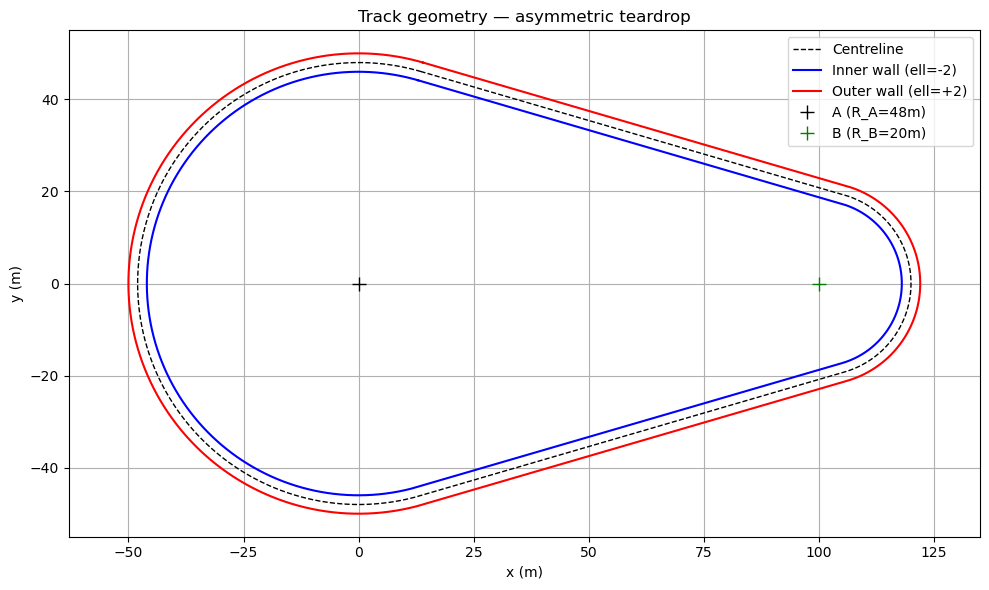

In [51]:
s_vals = np.linspace(0, L, 2000)
centre = np.array([s_to_xy(s)        for s in s_vals])
inner  = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer  = np.array([sl_to_xy(s, +2.0) for s in s_vals])

# Verify track width = 4 m at multiple points
print("Track width checks (should all be 4.000 m):")
for test_s in [0, s1/2, s1, s1 + l_arc_A/4, s2, s2 + l_tan/2, s3, s3 + l_arc_B/2]:
    inn = sl_to_xy(test_s, -2.0)
    out = sl_to_xy(test_s, +2.0)
    print(f"  s={test_s:6.1f}: width = {np.linalg.norm(out - inn):.4f} m")

# Verify normals are unit vectors
print("\nNormal unit length checks (should all be 1.000000):")
for test_s in [0, s1/2, s1, s1 + l_arc_A/4, s2, s2 + l_tan/2, s3]:
    n = s_to_normal(test_s)
    print(f"  s={test_s:6.1f}: |n| = {np.linalg.norm(n):.6f}")

plt.figure(figsize=(10, 6))
plt.plot(centre[:,0], centre[:,1], 'k--', lw=1,   label='Centreline')
plt.plot(inner[:,0],  inner[:,1],  'b-',  lw=1.5, label='Inner wall (ell=-2)')
plt.plot(outer[:,0],  outer[:,1],  'r-',  lw=1.5, label='Outer wall (ell=+2)')
plt.plot(*A_centre, 'k+', ms=10, label=f'A (R_A={R_A:.0f}m)')
plt.plot(*B_centre, 'g+', ms=10, label=f'B (R_B={R_B:.0f}m)')
plt.axis('equal')
plt.grid(True)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Track geometry — asymmetric teardrop')
plt.legend()
plt.tight_layout()
plt.savefig('figures/track_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# ── A2: Vehicle motion model ──────────────────────────────────────────────────
h = 0.01  # sampling time (100 Hz, problem statement)

# State: z_t = [s_t, ell_t, vs_t, vl_t]
# Constraints: vs in (0, 25] m/s, ell in [-2, 2] m

# ── Longitudinal velocity: AR(1) ─────────────────────────────────────────────
# phi_vs < 1 prevents unbounded random walk.
# phi_vs = 0.999 gives half-life ≈ 693 steps (6.9 s), adequate for 30 s race.
# Note: model is centred at 0, not 10 m/s; EKF measurements correct the bias.
phi_vs = 0.999

# ── Lateral dynamics: spring-damper (driver model) ───────────────────────────
# Models a driver who steers back to centreline:
#   vl_{t+1} = phi_1 * vl_t - h*k2 * ell_t + w_ell
# phi_1: damping (velocity decays), k2: restoring force (spring)
# This guarantees ell remains bounded over infinite time.
phi_1 = 0.9    # lateral damping
k2    = 10.0   # restoring gain

A = np.array([
    [1,      0,       h,      0    ],   # s_{t+1}   = s_t + h*vs_t
    [0,      1,       0,      h    ],   # ell_{t+1} = ell_t + h*vl_t
    [0,      0,       phi_vs, 0    ],   # vs_{t+1}  = phi_vs*vs_t + w_s
    [0,      -h*k2,   0,      phi_1],   # vl_{t+1}  = phi_1*vl_t - h*k2*ell_t + w_ell
])

G = np.array([
    [0, 0],
    [0, 0],
    [1, 0],
    [0, 1]
])

# Stability check
eigs = np.linalg.eigvals(A)
print(f"Eigenvalues of A: {np.round(eigs, 6)}")
print(f"All |eigenvalues| <= 1: {all(abs(e) <= 1.0 + 1e-10 for e in eigs)}")
print(f"\nA =\n{A}")
print(f"\nG =\n{G}")

Eigenvalues of A: [0.91127 0.98873 1.      0.999  ]
All |eigenvalues| <= 1: True

A =
[[ 1.     0.     0.01   0.   ]
 [ 0.     1.     0.     0.01 ]
 [ 0.     0.     0.999  0.   ]
 [ 0.    -0.1    0.     0.9  ]]

G =
[[0 0]
 [0 0]
 [1 0]
 [0 1]]


In [53]:
# Process noise covariance Q
# q_s   = 0.5  : longitudinal velocity noise
# q_ell = 0.003: lateral velocity noise
#                validated by Monte Carlo below: max|vl|<0.55 m/s, max|ell|<2 m
Q = np.diag([0.5, 0.003])

# Measurement noise (problem statement: sigma = 1.5 m)
R_meas = 1.5**2

# Full 4x4 process noise covariance
# Position rows/cols are zero (noise only enters through velocity states)
Qbar = G @ Q @ G.T

print("Q =", Q)
print(f"\nR_meas = {R_meas} m²  (sigma = 1.5 m)")
print("\nQbar =")
print(Qbar)

Q = [[0.5   0.   ]
 [0.    0.003]]

R_meas = 2.25 m²  (sigma = 1.5 m)

Qbar =
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.5   0.   ]
 [0.    0.    0.    0.003]]


In [54]:
# ── Initial conditions ────────────────────────────────────────────────────────
z0 = np.array([[0.0], [0.0], [10.0], [0.0]])
# [s=0: start of upper straight,
#  ell=0: on centreline,
#  vs=10 m/s: nominal speed (problem statement),
#  vl=0: no initial lateral motion]

# P0 diagonal: reflects prior uncertainty at t=0
#   100.0: arc-length uncertainty (±10 m)
#   1.0  : lateral offset uncertainty (know vehicle near centreline)
#   25.0 : speed uncertainty (±5 m/s around 10 m/s)
#   0.5  : lateral velocity uncertainty
P0 = np.diag([100.0, 1.0, 25.0, 0.5])

print("z0 =", z0.T)
print("\nP0 =")
print(P0)

z0 = [[ 0.  0. 10.  0.]]

P0 =
[[100.    0.    0.    0. ]
 [  0.    1.    0.    0. ]
 [  0.    0.   25.    0. ]
 [  0.    0.    0.    0.5]]


In [55]:
# ── A1 verification: continuity at segment junctions ─────────────────────────
print("Track continuity (gap should be ~0 mm):")
for s_bnd, name in [(s1, 'P2: upper straight → large arc'),
                     (s2, 'P3: large arc → lower straight'),
                     (s3, 'P4: lower straight → small arc'),
                     (L,  'P1: small arc → upper straight (wrap)')]:
    p1 = s_to_xy(s_bnd - 0.001)
    p2 = s_to_xy(s_bnd + 0.001)
    print(f"  s={s_bnd:.2f} ({name}): gap = {np.linalg.norm(p1-p2)*1000:.2f} mm")

print("\nNormal continuity at junctions:")
for s_bnd, name in [(s1, 'upper straight / large arc'),
                     (s2, 'large arc / lower straight'),
                     (s3, 'lower straight / small arc')]:
    n1 = s_to_normal(s_bnd - 0.001)
    n2 = s_to_normal(s_bnd + 0.001)
    print(f"  s={s_bnd:.2f} ({name}): |Δn| = {np.linalg.norm(n1-n2):.6f}")

Track continuity (gap should be ~0 mm):
  s=96.00 (P2: upper straight → large arc): gap = 2.00 mm
  s=147.48 (P3: large arc → lower straight): gap = 2.00 mm
  s=243.48 (P4: lower straight → small arc): gap = 2.00 mm
  s=421.52 (P1: small arc → upper straight (wrap)): gap = 2.00 mm

Normal continuity at junctions:
  s=96.00 (upper straight / large arc): |Δn| = 0.000050
  s=147.48 (large arc / lower straight): |Δn| = 0.000050
  s=243.48 (lower straight / small arc): |Δn| = 0.000021


Running 100 trials × 3000 steps (30 s each)...

Over 100 trials:
  Max |ell| = 0.170 m     (bound: 2.0 m)
  Max |vl|  = 0.550 m/s   (bound: 0.55 m/s)
  Max vs    = 25.000 m/s   (bound: 25.0 m/s)


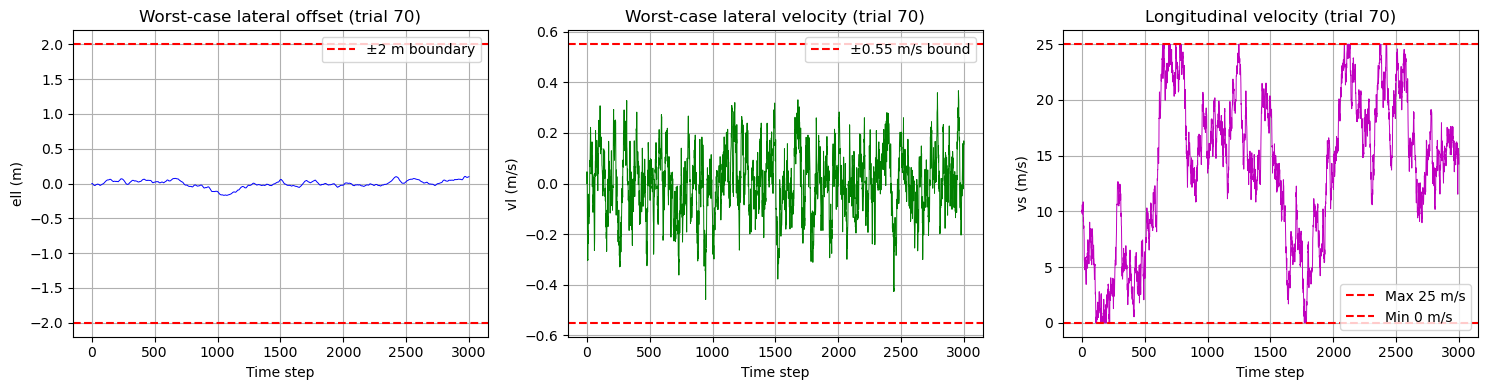

In [58]:
# ── A2 verification: spring-damper keeps lateral motion bounded ───────────────
# Run 100 trials of 3000 steps each to validate worst-case behaviour
print("Running 100 trials × 3000 steps (30 s each)...")

max_ell_all = []
max_vl_all  = []
max_vs_all  = []

for trial in range(100):
    np.random.seed(trial)
    ell_sim = [0.0]
    vl_sim  = [0.0]
    vs_sim  = [10.0]
    for _ in range(3000):
        w_ell = np.random.normal(0, np.sqrt(Q[1, 1]))
        w_s   = np.random.normal(0, np.sqrt(Q[0, 0]))

        # Explicit Euler — matches A matrix exactly
        ell_new = ell_sim[-1] + h * vl_sim[-1]
        vl_new  = phi_1 * vl_sim[-1] - h * k2 * ell_sim[-1] + w_ell
        # OU process centred at 10 m/s
        vs_new  = phi_vs * vs_sim[-1] + 10.0 * (1 - phi_vs) + w_s

        # Hard constraints: enforce physical limits strictly
        vs_new  = np.clip(vs_new,  0.001, 25.0)   # never backwards, never > 25 m/s
        vl_new  = np.clip(vl_new,  -0.55, 0.55)   # lateral velocity limit
        ell_new = np.clip(ell_new, -2.0,  2.0)    # never outside track

        vl_sim.append(vl_new)
        ell_sim.append(ell_new)
        vs_sim.append(vs_new)

    max_ell_all.append(max(abs(e) for e in ell_sim))
    max_vl_all.append(max(abs(v) for v in vl_sim))
    max_vs_all.append(max(vs_sim))

print(f"\nOver 100 trials:")
print(f"  Max |ell| = {max(max_ell_all):.3f} m     (bound: 2.0 m)")
print(f"  Max |vl|  = {max(max_vl_all):.3f} m/s   (bound: 0.55 m/s)")
print(f"  Max vs    = {max(max_vs_all):.3f} m/s   (bound: 25.0 m/s)")

# Plot worst-case trial
worst = max_ell_all.index(max(max_ell_all))
np.random.seed(worst)
ell_sim = [0.0]; vl_sim = [0.0]; vs_sim = [10.0]
for _ in range(3000):
    w_ell = np.random.normal(0, np.sqrt(Q[1, 1]))
    w_s   = np.random.normal(0, np.sqrt(Q[0, 0]))
    ell_new = ell_sim[-1] + h * vl_sim[-1]
    vl_new  = phi_1 * vl_sim[-1] - h * k2 * ell_sim[-1] + w_ell
    vs_new  = phi_vs * vs_sim[-1] + 10.0 * (1 - phi_vs) + w_s
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new,  -0.55, 0.55)
    ell_new = np.clip(ell_new, -2.0,  2.0)
    vl_sim.append(vl_new); ell_sim.append(ell_new); vs_sim.append(vs_new)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ell_sim, 'b-', lw=0.7)
axes[0].axhline(+2.0, color='r', ls='--', label='±2 m boundary')
axes[0].axhline(-2.0, color='r', ls='--')
axes[0].set_xlabel('Time step'); axes[0].set_ylabel('ell (m)')
axes[0].set_title(f'Worst-case lateral offset (trial {worst})')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(vl_sim, 'g-', lw=0.7)
axes[1].axhline(+0.55, color='r', ls='--', label='±0.55 m/s bound')
axes[1].axhline(-0.55, color='r', ls='--')
axes[1].set_xlabel('Time step'); axes[1].set_ylabel('vl (m/s)')
axes[1].set_title(f'Worst-case lateral velocity (trial {worst})')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(vs_sim, 'm-', lw=0.7)
axes[2].axhline(25.0, color='r', ls='--', label='Max 25 m/s')
axes[2].axhline(0.0,  color='r', ls='--', label='Min 0 m/s')
axes[2].set_xlabel('Time step'); axes[2].set_ylabel('vs (m/s)')
axes[2].set_title(f'Longitudinal velocity (trial {worst})')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig('figures/lateral_bounds.png', dpi=150, bbox_inches='tight')
plt.show

In [59]:
# ── A3: Beacon placement optimisation ────────────────────────────────────────
# Method: GDOP (Geometric Dilution of Precision) minimisation
# Reference: Langley (1999), "Dilution of Precision", GPS World
#
# GDOP = sqrt(trace((H^T H)^{-1}))
# where H_i = (p - b_i) / ||p - b_i||  (unit vector from beacon to vehicle)
#
# We minimise mean GDOP over 100 sampled points along the centreline.
# Algorithm: greedy search (near-optimal, computationally tractable)
# Note: n=1 cannot localise in 2D (H^T H is rank-deficient), so we
# start by exhaustively searching all pairs for n=2, then greedily add.

n_track_pts = 100
s_samples   = np.linspace(0, L, n_track_pts, endpoint=False)
track_pts   = np.array([s_to_xy(s) for s in s_samples])

def compute_gdop(vehicle_pos, beacons):
    """
    GDOP at vehicle_pos for a set of beacons.
    Returns inf if fewer than 2 beacons or H^T H is singular.
    """
    beacons = np.atleast_2d(beacons)
    if len(beacons) < 2:
        return np.inf
    diff  = vehicle_pos - beacons
    dists = np.linalg.norm(diff, axis=1)
    if np.any(dists < 1e-6):
        return np.inf
    H = diff / dists[:, None]
    try:
        HtH = H.T @ H
        if np.linalg.matrix_rank(HtH) < 2:
            return np.inf
        return np.sqrt(np.trace(np.linalg.inv(HtH)))
    except np.linalg.LinAlgError:
        return np.inf

def mean_gdop(beacons):
    """Mean GDOP over all sampled track positions."""
    gdops = np.array([compute_gdop(p, beacons) for p in track_pts])
    valid = gdops[np.isfinite(gdops)]
    return np.mean(valid) if len(valid) > 0 else np.inf

print("GDOP functions ready.")

GDOP functions ready.


In [60]:
# ── Candidate beacon positions (outside track) ───────────────────────────────
def is_outside_track(point, margin=5.0):
    """True if point is at least (track half-width + margin) from centreline."""
    dists = np.linalg.norm(track_pts - point, axis=1)
    return np.min(dists) > (w + margin)

x_grid = np.linspace(-100, 200, 15)
y_grid = np.linspace(-100, 100, 12)

candidates = np.array([
    np.array([x, y])
    for x in x_grid for y in y_grid
    if is_outside_track(np.array([x, y]))
])

print(f"Candidate positions: {len(candidates)}")
print(f"Search region: x in [-100, 200], y in [-100, 100]")
print(f"Margin from track: 5 m (track half-width {w:.1f} m + 5 m buffer)")

Candidate positions: 166
Search region: x in [-100, 200], y in [-100, 100]
Margin from track: 5 m (track half-width 2.0 m + 5 m buffer)


In [61]:
# ── Greedy beacon search (n = 2 to 6) ────────────────────────────────────────
# Step 1: exhaustive search for best pair (n=2)
print("Step 1: Exhaustive search for best 2-beacon pair...")
best_gdop_2 = np.inf
best_pair   = None
for i in range(len(candidates)):
    for j in range(i+1, len(candidates)):
        g = mean_gdop(candidates[[i, j]])
        if g < best_gdop_2:
            best_gdop_2 = g
            best_pair   = candidates[[i, j]].copy()
print(f"  Best 2-beacon mean GDOP = {best_gdop_2:.4f}")

# Step 2: greedy add beacons 3 to 6
results = {2: {'gdop': best_gdop_2, 'beacons': best_pair}}
current = best_pair.copy()

for n in range(3, 7):
    best_g = np.inf; best_pt = None
    for pt in candidates:
        if any(np.allclose(pt, b) for b in current):
            continue
        g = mean_gdop(np.vstack([current, pt]))
        if g < best_g:
            best_g = g; best_pt = pt.copy()
    current = np.vstack([current, best_pt])
    results[n] = {'gdop': best_g, 'beacons': current.copy()}
    print(f"  Best {n}-beacon mean GDOP = {best_g:.4f}")

print("\nGreedy search complete.")

Step 1: Exhaustive search for best 2-beacon pair...
  Best 2-beacon mean GDOP = 1.5050
  Best 3-beacon mean GDOP = 1.2010
  Best 4-beacon mean GDOP = 1.0273
  Best 5-beacon mean GDOP = 0.9070
  Best 6-beacon mean GDOP = 0.8272

Greedy search complete.


   N   Mean GDOP    Improvement    Exp. error
   2      1.5050           0.0%       2.257 m
   3      1.2010          20.2%       1.802 m
   4      1.0273          14.5%       1.541 m
   5      0.9070          11.7%       1.360 m ◄ selected
   6      0.8272           8.8%       1.241 m

Recommended: 5 beacons (next beacon gives <10% improvement)

Optimal beacon positions:
  Beacon 1: (-57.1, 100.0)
  Beacon 2: (157.1, 100.0)
  Beacon 3: (50.0, -45.5)
  Beacon 4: (28.6, 100.0)
  Beacon 5: (-100.0, 9.1)


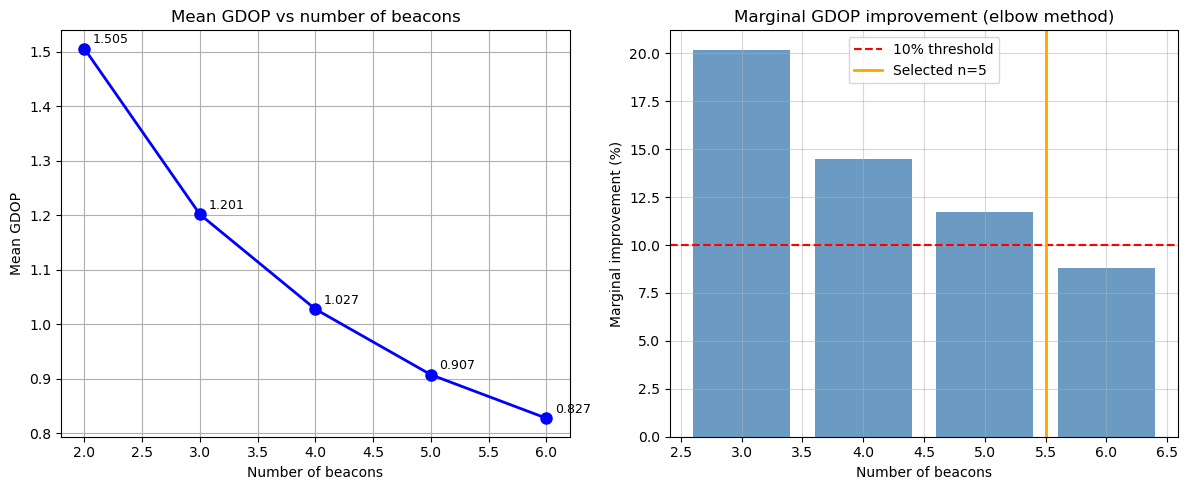

In [62]:
# ── Elbow method: choose optimal number of beacons ───────────────────────────
ns    = list(results.keys())
gdops = [results[n]['gdop'] for n in ns]
imps  = [0.0] + [
    (gdops[i-1] - gdops[i]) / gdops[i-1] * 100
    for i in range(1, len(gdops))
]

# Threshold: if marginal improvement < 10%, extra beacon not worth cost
threshold = 10.0
opt_n = None
for i in range(1, len(ns)):
    if imps[i] < threshold:
        opt_n = ns[i-1]
        break
if opt_n is None:
    opt_n = ns[-1]

print("=" * 58)
print(f"{'N':>4}  {'Mean GDOP':>10}  {'Improvement':>13}  {'Exp. error':>12}")
print("=" * 58)
for i, n in enumerate(ns):
    marker = " ◄ selected" if n == opt_n else ""
    print(f"{n:>4}  {gdops[i]:>10.4f}  {imps[i]:>12.1f}%"
          f"  {gdops[i]*1.5:>10.3f} m{marker}")
print("=" * 58)
print(f"\nRecommended: {opt_n} beacons "
      f"(next beacon gives <{threshold:.0f}% improvement)")
print(f"\nOptimal beacon positions:")
for i, b in enumerate(results[opt_n]['beacons']):
    print(f"  Beacon {i+1}: ({b[0]:.1f}, {b[1]:.1f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(ns, gdops, 'bo-', lw=2, ms=8)
for i, n in enumerate(ns):
    axes[0].annotate(f'{gdops[i]:.3f}', (n, gdops[i]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[0].set_xlabel('Number of beacons')
axes[0].set_ylabel('Mean GDOP')
axes[0].set_title('Mean GDOP vs number of beacons')
axes[0].grid(True)

axes[1].bar(ns[1:], imps[1:], color='steelblue', alpha=0.8)
axes[1].axhline(threshold, color='r', ls='--', lw=1.5,
                label=f'{threshold:.0f}% threshold')
axes[1].axvline(opt_n + 0.5, color='orange', ls='-', lw=2,
                label=f'Selected n={opt_n}')
axes[1].set_xlabel('Number of beacons')
axes[1].set_ylabel('Marginal improvement (%)')
axes[1].set_title('Marginal GDOP improvement (elbow method)')
axes[1].legend(); axes[1].grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('figures/beacon_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

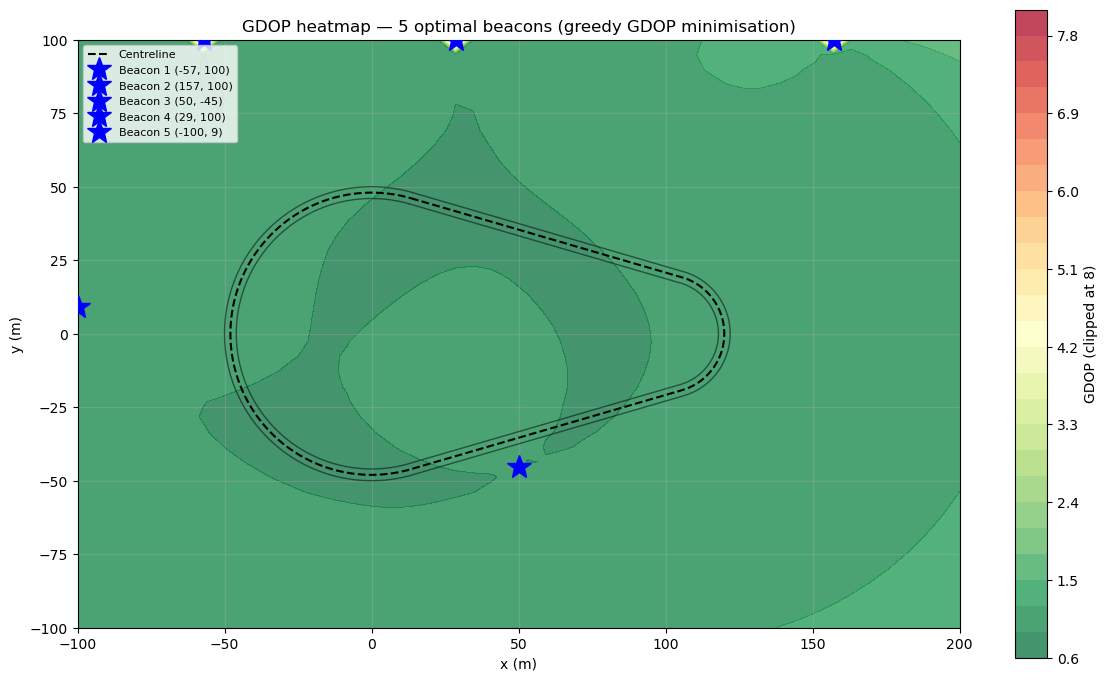

In [63]:
# ── GDOP heatmap ─────────────────────────────────────────────────────────────
opt_beacons = results[opt_n]['beacons']
s_vals  = np.linspace(0, L, 1000)
centre  = np.array([s_to_xy(s)        for s in s_vals])
inner   = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer   = np.array([sl_to_xy(s, +2.0) for s in s_vals])

x_heat = np.linspace(-100, 200, 50)
y_heat = np.linspace(-100, 100, 40)
XX, YY = np.meshgrid(x_heat, y_heat)
ZZ = np.zeros_like(XX)
for i in range(XX.shape[0]):
    for j in range(XX.shape[1]):
        ZZ[i, j] = compute_gdop(np.array([XX[i,j], YY[i,j]]), opt_beacons)
ZZ_clip = np.clip(ZZ, 0, 8)

fig, ax = plt.subplots(figsize=(12, 7))
hm = ax.contourf(XX, YY, ZZ_clip, levels=25, cmap='RdYlGn_r', alpha=0.75)
plt.colorbar(hm, ax=ax, label='GDOP (clipped at 8)')
ax.plot(centre[:,0], centre[:,1], 'k--', lw=1.5, label='Centreline', zorder=3)
ax.plot(inner[:,0],  inner[:,1],  'k-',  lw=1,   alpha=0.5, zorder=3)
ax.plot(outer[:,0],  outer[:,1],  'k-',  lw=1,   alpha=0.5, zorder=3)
for i, b in enumerate(opt_beacons):
    ax.plot(b[0], b[1], 'b*', ms=18, zorder=5,
            label=f'Beacon {i+1} ({b[0]:.0f}, {b[1]:.0f})')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title(f'GDOP heatmap — {opt_n} optimal beacons (greedy GDOP minimisation)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('figures/beacon_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Baseline mean GDOP = 0.9070
Perturbation = ±10 m

Beacon 1 (-57, 100):
  +x: GDOP = 0.9072  (+0.0%)
  -x: GDOP = 0.9077  (+0.1%)
  +y: GDOP = 0.9063  (-0.1%)
  -y: GDOP = 0.9081  (+0.1%)
Beacon 2 (157, 100):
  +x: GDOP = 0.9078  (+0.1%)
  -x: GDOP = 0.9066  (-0.0%)
  +y: GDOP = 0.9066  (-0.0%)
  -y: GDOP = 0.9077  (+0.1%)
Beacon 3 (50, -45):
  +x: GDOP = 0.9079  (+0.1%)
  -x: GDOP = 0.9068  (-0.0%)
  +y: GDOP = 0.9080  (+0.1%)
  -y: GDOP = 0.9072  (+0.0%)
Beacon 4 (29, 100):
  +x: GDOP = 0.9070  (-0.0%)
  -x: GDOP = 0.9079  (+0.1%)
  +y: GDOP = 0.9052  (-0.2%)
  -y: GDOP = 0.9094  (+0.3%)
Beacon 5 (-100, 9):
  +x: GDOP = 0.9070  (+0.0%)
  -x: GDOP = 0.9071  (+0.0%)
  +y: GDOP = 0.9073  (+0.0%)
  -y: GDOP = 0.9073  (+0.0%)


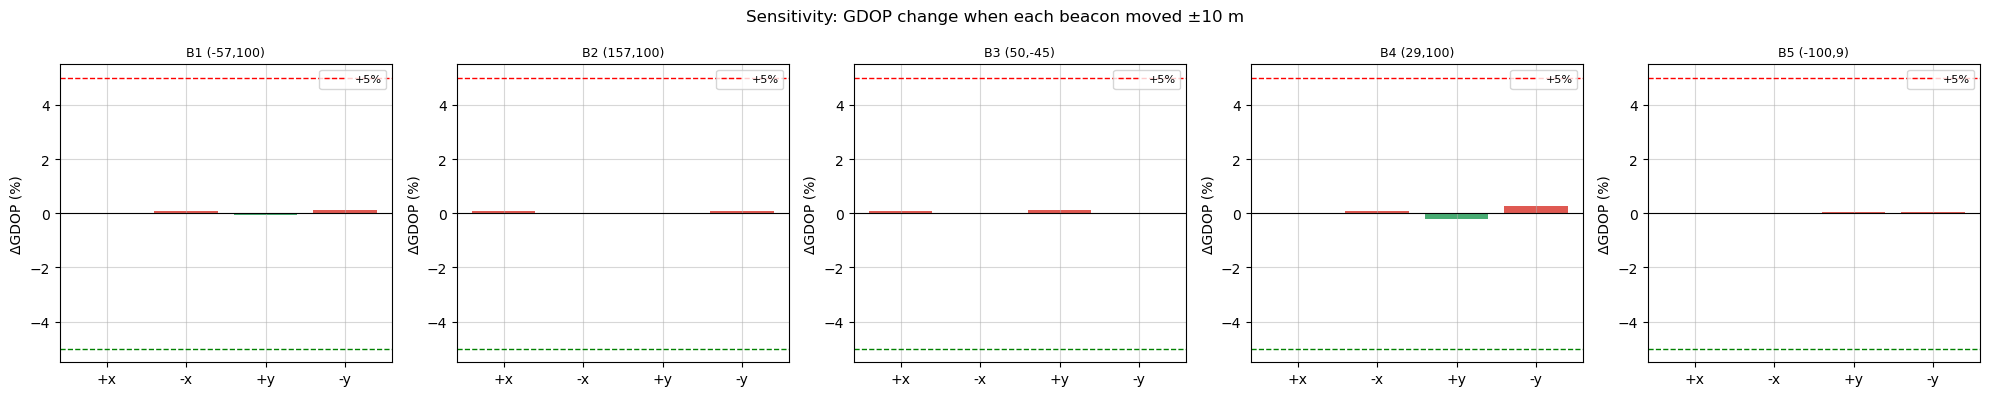

In [64]:
# ── Sensitivity analysis ──────────────────────────────────────────────────────
# Perturb each beacon ±10 m in x and y; measure GDOP change
base_gdop = results[opt_n]['gdop']
perturb   = 10.0
dirs = {'+x': np.array([1,0]), '-x': np.array([-1,0]),
        '+y': np.array([0,1]), '-y': np.array([ 0,-1])}

print(f"Baseline mean GDOP = {base_gdop:.4f}")
print(f"Perturbation = ±{perturb:.0f} m\n")

sens = {}
for i, b in enumerate(opt_beacons):
    sens[i] = {}
    print(f"Beacon {i+1} ({b[0]:.0f}, {b[1]:.0f}):")
    for name, direction in dirs.items():
        pert    = opt_beacons.copy()
        pert[i] = b + perturb * direction
        g       = mean_gdop(pert)
        delta   = (g - base_gdop) / base_gdop * 100
        sens[i][name] = delta
        print(f"  {name}: GDOP = {g:.4f}  ({delta:+.1f}%)")

fig, axes = plt.subplots(1, opt_n, figsize=(4*opt_n, 4))
if opt_n == 1: axes = [axes]
dir_names = list(dirs.keys())
for i in range(opt_n):
    vals   = [sens[i][d] for d in dir_names]
    colors = ['#d73027' if v > 0 else '#1a9850' for v in vals]
    axes[i].bar(dir_names, vals, color=colors, alpha=0.8)
    axes[i].axhline(0,  color='k',  lw=0.8)
    axes[i].axhline(+5, color='r',  ls='--', lw=1, label='+5%')
    axes[i].axhline(-5, color='g',  ls='--', lw=1)
    b = opt_beacons[i]
    axes[i].set_title(f'B{i+1} ({b[0]:.0f},{b[1]:.0f})', fontsize=9)
    axes[i].set_ylabel('ΔGDOP (%)')
    axes[i].legend(fontsize=8); axes[i].grid(True, alpha=0.5)
plt.suptitle(f'Sensitivity: GDOP change when each beacon moved ±{perturb:.0f} m')
plt.tight_layout()
plt.savefig('figures/beacon_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
# ── Final beacon coordinates (for EKF implementation) ────────────────────────
print("=" * 50)
print("FINAL BEACON COORDINATES")
print("Pass these to your EKF code:")
print("=" * 50)
print(f"\nbeacons = np.array([")
for i, b in enumerate(results[opt_n]['beacons']):
    print(f"    [{b[0]:.1f}, {b[1]:.1f}],   # Beacon {i+1}")
print(f"])")
print(f"\nNumber of beacons: {opt_n}")
print(f"Mean GDOP: {results[opt_n]['gdop']:.4f}")
print(f"Expected position error: {results[opt_n]['gdop']*1.5:.3f} m")

FINAL BEACON COORDINATES
Pass these to your EKF code:

beacons = np.array([
    [-57.1, 100.0],   # Beacon 1
    [157.1, 100.0],   # Beacon 2
    [50.0, -45.5],   # Beacon 3
    [28.6, 100.0],   # Beacon 4
    [-100.0, 9.1],   # Beacon 5
])

Number of beacons: 5
Mean GDOP: 0.9070
Expected position error: 1.360 m
